# Tarification optimisée — sélectionner et livrer la meilleure paire testée

Ce notebook assemble les catalogues de `modele_frequence_ameliore.ipynb` et `modele_gravite_ameliore.ipynb`. Il utilise uniquement leurs artefacts créés localement, avec contrôle des empreintes des données et des identifiants. Les fonctions/classes sérialisées contiennent la préparation et le modèle ; leur code source reste intégralement visible dans les notebooks individuels.

La fréquence apprend sur tous les contrats d'apprentissage ; Gamma seulement sur les sinistrés. Chaque prospect reçoit une **prime pure = probabilité × gravité conditionnelle**. La soumission contient **index,pred**, avec les identifiants 50 000 à 99 999 confirmés par l'équipe.

Nous cherchons le meilleur candidat testé, sans promettre un optimum universel. La validation historique reste réservée au diagnostic : elle ne choisit pas les paramètres.

In [1]:
import os
os.environ['OMP_NUM_THREADS']='2'
os.environ['OPENBLAS_NUM_THREADS']='2'
from pathlib import Path
import json,hashlib,time,sys,platform,subprocess,warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cloudpickle,sklearn
from IPython.display import display,Markdown
from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler,OneHotEncoder,SplineTransformer,FunctionTransformer
from sklearn.linear_model import LogisticRegression,GammaRegressor
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import GroupShuffleSplit,StratifiedGroupKFold,GroupKFold
from sklearn.metrics import log_loss,brier_score_loss,roc_auc_score,root_mean_squared_error,mean_absolute_error,mean_squared_error
from sklearn.exceptions import ConvergenceWarning
from threadpoolctl import threadpool_limits
threadpool_limits(limits=2)
warnings.filterwarnings('error',category=ConvergenceWarning)
racines=[Path.cwd(),Path.cwd()/'TD-Tarification-automobile-par-Machine-Learning']
ROOT=next(p for p in racines if (p/'Data/train.csv').exists())
BASE_OUTPUT=ROOT/'output/optimisation'
BASE_OUTPUT.mkdir(parents=True,exist_ok=True)
SEED=42
train=pd.read_csv(ROOT/'Data/train.csv',dtype={'code_postal':str})
test=pd.read_csv(ROOT/'Data/test.csv',dtype={'code_postal':str})
ii,jj=next(GroupShuffleSplit(n_splits=1,test_size=.2,random_state=SEED).split(train,groups=train.id_client))
dev=train.iloc[ii].copy();valid=train.iloc[jj].copy()
assert set(dev.id_client).isdisjoint(valid.id_client)
assert train['index'].is_unique and test['index'].is_unique
assert set(train.nombre_sinistres.unique())=={0,1}
assert ((train.nombre_sinistres==0)==(train.montant_sinistre==0)).all()
CV_MAIN=StratifiedGroupKFold(n_splits=5,shuffle=True,random_state=20261009)
MAIN_SPLITS=list(CV_MAIN.split(dev,dev.nombre_sinistres,groups=dev.id_client))
DATA_HASH={name:hashlib.sha256((ROOT/'Data'/name).read_bytes()).hexdigest() for name in ['train.csv','test.csv']}
print('Apprentissage commun :',len(dev),'contrats et',int(dev.nombre_sinistres.sum()),'sinistres.')
print('Diagnostic historique réservé :',len(valid),'contrats ; aucune sélection sur ces cibles.')

Apprentissage commun : 40013 contrats et 2352 sinistres.
Diagnostic historique réservé : 9987 contrats ; aucune sélection sur ces cibles.


## 1. Comparer les paires sur les primes

Les deux catalogues ont exactement les mêmes cinq plis clients. Pour chaque paire, nous multiplions les prédictions hors pli et calculons la MSE du coût réel sur **tous** les contrats, y compris ceux sans sinistre. La paire de référence corrigée est incluse. La recherche de nombreuses paires rend le meilleur score optimiste : l'étape suivante évalue la procédure entière.

In [2]:
OUT=BASE_OUTPUT/'prime';OUT.mkdir(parents=True,exist_ok=True)
with (BASE_OUTPUT/'frequence/fabrique.pkl').open('rb') as f:F=cloudpickle.load(f)
with (BASE_OUTPUT/'gravite/fabrique.pkl').open('rb') as f:G=cloudpickle.load(f)
# Les fabriques chargées utilisent le répertoire du projet courant, même après un clone ailleurs.
for fabrique in [F,G]:
    for cle in ['make','batch']:
        fabrique[cle].__globals__['BASE_OUTPUT']=BASE_OUTPUT
FREQUENCES=F['configs'];GRAVITES=G['configs']
fnames=[c['name'] for c in FREQUENCES];gnames=[c['name'] for c in GRAVITES]
for component in ['frequence','gravite']:
    info=json.loads((BASE_OUTPUT/component/'catalogue.json').read_text())
    assert info['sha256_data']==DATA_HASH,'Les données ont changé : recalculer les catalogues.'
ff=np.load(BASE_OUTPUT/'frequence/predictions_oof.npz')
gg=np.load(BASE_OUTPUT/'gravite/predictions_oof.npz')
np.testing.assert_array_equal(ff['ids'],dev['index'])
np.testing.assert_array_equal(gg['ids'],dev['index'])
assert list(ff['names'])==fnames and list(gg['names'])==gnames
P=ff['predictions'];S=gg['predictions']

def classement_paires(p,s,y):
    rows=[]
    for i,fname in enumerate(fnames):
        for j,gname in enumerate(gnames):
            mse=float(np.mean((p[:,i]*s[:,j]-np.asarray(y))**2))
            rows.append({'frequence':fname,'gravite':gname,'i':i,'j':j,'MSE_prime':mse,'RMSE_prime':np.sqrt(mse)})
    return pd.DataFrame(rows).sort_values(['MSE_prime','i','j']).reset_index(drop=True)

ranking=classement_paires(P,S,dev.montant_sinistre)
ranking.to_csv(OUT/'comparaison_paires_cv.csv',index=False)
best=ranking.iloc[0];fi=int(best.i);gi=int(best.j)
fconfig=FREQUENCES[fi];gconfig=GRAVITES[gi]
display(ranking.head(15))
print('Paire sélectionnée uniquement sur le développement :',fconfig['name'],'×',gconfig['name'])
print('RMSE OOF de sélection :',best.RMSE_prime,'€ — estimation optimiste après recherche.')

Paire sélectionnée uniquement sur le développement : Melange_logistique_boosting_0.75 × Gamma_3_variables_a0.01
RMSE OOF de sélection : 550.2071927040317 € — estimation optimiste après recherche.


,frequence,gravite,i,j,MSE_prime,RMSE_prime
0,Melange_logistique_boosting_0.75,Gamma_3_variables_a0.01,16,2,302727.954903,550.207193
1,Melange_logistique_boosting_0.75,Gamma_reference_3_variables,16,0,302730.958460,550.209922
2,Melange_logistique_boosting_0.75,Gamma_3_variables_a0.001,16,1,302732.670622,550.211478
3,Melange_logistique_boosting_0.75,Gamma_3_variables_a1.0,16,3,302758.651164,550.235087
4,Melange_logistique_boosting_0.75,Gamma_cout_modele_lisse20_a1.0,16,19,302774.339226,550.249343
5,Melange_logistique_boosting_0.75,Gamma_cout_modele_lisse100_a1.0,16,21,302775.524535,550.250420
6,Melange_logistique_boosting_0.75,Gamma_cout_modele_lisse20_a0.1,16,18,302779.462554,550.253998
7,Melange_logistique_boosting_0.75,Gamma_cout_modele_lisse100_a0.1,16,20,302781.616235,550.255955
8,Melange_logistique_boosting_0.75,Gamma_compact_a1.0,16,8,302783.918589,550.258047
9,Melange_logistique_boosting_0.75,Gamma_compact_a0.1,16,7,302786.614395,550.260497


## 2. Validation imbriquée de la sélection complète

Trois plis externes réservent des clients. Dans chacun, trois plis internes recommencent la comparaison de tous les candidats et de leurs paires, avec les préparations, encodages de cible et calibrations appris exclusivement dans les clients autorisés. Le gagnant interne est réentraîné dans l'apprentissage externe, puis prédit le pli externe exclu.

Nous évaluons aussi la paire de référence fixe et une prime constante sur les mêmes plis externes. Le score global utilise toutes les prédictions externes assemblées. La procédure évaluée utilise trois plis internes ; la sélection finale sur tout le développement en utilise cinq. L'évaluation imbriquée reste un diagnostic interne de données déjà explorées et n'efface pas les choix méthodologiques antérieurs.

In [3]:
outer=StratifiedGroupKFold(n_splits=3,shuffle=True,random_state=20261010)
nested=np.full(len(dev),np.nan);nested_ref=np.full(len(dev),np.nan);nested_constant=np.full(len(dev),np.nan)
nested_rows=[];started=time.perf_counter()
for fold,(a,b) in enumerate(outer.split(dev,dev.nombre_sinistres,groups=dev.id_client),1):
    learn=dev.iloc[a];eval_frame=dev.iloc[b]
    assert set(learn.id_client).isdisjoint(eval_frame.id_client)
    inner=StratifiedGroupKFold(n_splits=3,shuffle=True,random_state=3200+fold)
    pi=np.full((len(learn),len(FREQUENCES)),np.nan)
    si=np.full((len(learn),len(GRAVITES)),np.nan)
    for inner_fold,(ia,ib) in enumerate(inner.split(learn,learn.nombre_sinistres,groups=learn.id_client),1):
        learning=learn.iloc[ia];evaluation=learn.iloc[ib]
        assert set(learning.id_client).isdisjoint(evaluation.id_client)
        pi[ib]=F['batch'](learning,learning.nombre_sinistres,learning.id_client,evaluation,FREQUENCES)
        claims=learning.loc[learning.nombre_sinistres.eq(1)]
        si[ib]=G['batch'](claims,claims.montant_sinistre,claims.id_client,evaluation,GRAVITES)
        (BASE_OUTPUT/'progression.json').write_text(json.dumps({'etape':'CV imbriquee paire','pli_externe':fold,
            'pli_interne':inner_fold,'secondes':time.perf_counter()-started}))
        print('Imbriquée : externe',fold,'/ 3 ; interne',inner_fold,'/ 3 terminé.',flush=True)
    chosen=classement_paires(pi,si,learn.montant_sinistre).iloc[0]
    fsel=FREQUENCES[int(chosen.i)];gsel=GRAVITES[int(chosen.j)]
    fm=F['make'](fsel).fit(learn,learn.nombre_sinistres,learn.id_client)
    claims=learn.loc[learn.nombre_sinistres.eq(1)]
    gm=G['make'](gsel).fit(claims,claims.montant_sinistre,claims.id_client)
    nested[b]=fm.predict_proba(eval_frame)[:,1]*gm.predict(eval_frame)
    fr=F['make'](FREQUENCES[0]).fit(learn,learn.nombre_sinistres,learn.id_client)
    gr=G['make'](GRAVITES[0]).fit(claims,claims.montant_sinistre,claims.id_client)
    nested_ref[b]=fr.predict_proba(eval_frame)[:,1]*gr.predict(eval_frame)
    nested_constant[b]=learn.montant_sinistre.mean()
    nested_rows.append({'pli_externe':fold,'frequence':fsel['name'],'gravite':gsel['name'],
        'contrats_evalues':len(b),'RMSE_selection':root_mean_squared_error(eval_frame.montant_sinistre,nested[b]),
        'RMSE_reference':root_mean_squared_error(eval_frame.montant_sinistre,nested_ref[b])})
    pd.DataFrame(nested_rows).to_csv(OUT/'validation_imbriquee_plis.csv',index=False)
assert np.isfinite(nested).all() and np.isfinite(nested_ref).all()
nested_scores=pd.DataFrame([
    {'procedure':'Selection_paire_imbriquee','RMSE':root_mean_squared_error(dev.montant_sinistre,nested)},
    {'procedure':'Paire_reference_fixe','RMSE':root_mean_squared_error(dev.montant_sinistre,nested_ref)},
    {'procedure':'Prime_constante','RMSE':root_mean_squared_error(dev.montant_sinistre,nested_constant)}])
nested_scores.to_csv(OUT/'scores_validation_imbriquee.csv',index=False)
pd.DataFrame({'index':dev['index'],'cout_reel':dev.montant_sinistre,'pred_procedure':nested,
    'pred_reference':nested_ref,'pred_constante':nested_constant}).to_csv(OUT/'predictions_validation_imbriquee.csv',index=False)
display(pd.DataFrame(nested_rows))
display(nested_scores)
print('La sélection finale reste celle des cinq plis de développement. Les scores externes évaluent la procédure sans la retoucher.')

frequence Logistique_reference : 4.7 s
frequence Logistique_lineaire_prix_C0.1 : 0.4 s
frequence Logistique_lineaire_prix_C1.0 : 0.6 s
frequence Logistique_splines_prix_C0.1 : 0.5 s
frequence Logistique_splines_prix_C1.0 : 0.6 s
frequence Logistique_splines_interactions_C0.1 : 0.8 s
frequence Logistique_splines_interactions_C1.0 : 1.5 s
frequence Logistique_splines_geo_vehicules_C0.1 : 1.2 s
frequence Logistique_splines_geo_vehicules_C1.0 : 2.3 s
frequence Boosting_prudent : 0.9 s
frequence Boosting_souple : 1.6 s
frequence Boosting_regulier : 2.0 s
frequence Boosting_interactions : 2.1 s
frequence Boosting_souple_calibre : 7.6 s
gravite Gamma_reference_3_variables : 0.1 s
gravite Gamma_3_variables_a0.001 : 0.2 s
gravite Gamma_3_variables_a0.01 : 0.2 s
gravite Gamma_3_variables_a1.0 : 0.1 s
gravite Gamma_3_variables_a10.0 : 0.1 s
gravite Gamma_3_variables_a100.0 : 0.1 s
gravite Gamma_compact_a0.01 : 0.1 s
gravite Gamma_compact_a0.1 : 0.1 s
gravite Gamma_compact_a1.0 : 0.1 s
gravite Gam

,pli_externe,frequence,gravite,contrats_evalues,RMSE_selection,RMSE_reference
0,1,Logistique_splines_interactions_C0.1,Gamma_reference_3_variables,13338,571.334343,571.340028
1,2,Melange_logistique_boosting_0.75,Gamma_reference_3_variables,13338,550.505612,550.541761
2,3,Logistique_reference,Gamma_3_variables_a1.0,13337,528.465740,528.438833


,procedure,RMSE
0,Selection_paire_imbriquee,550.380829
1,Paire_reference_fixe,550.386238
2,Prime_constante,553.544917


## 3. Diagnostic historique, sans nouvelle sélection

Nous ajustons la paire retenue dans le développement puis prédisons la validation commune. L'ancienne paire est comparée sur les mêmes identifiants. Si le classement diffère ici, nous le signalons sans retoucher le gagnant. Le score de gravité porte seulement sur les sinistrés ; le RMSE de prime concerne tout le portefeuille.

,RMSE_EUR,MSE_EUR2,MAE_EUR,biais_EUR,ratio_total
Paire_optimisee,507.598671,257656.411078,190.248227,2.636362,1.025902
Paire_precedente,507.647017,257705.493812,190.377361,2.692806,1.026457
Prime_constante,511.466496,261597.976209,193.805454,1.985642,1.019509


,log_loss_frequence,Brier_frequence,AUC_frequence,RMSE_gravite_sinistres
0,0.20755,0.052273,0.671075,1245.716617


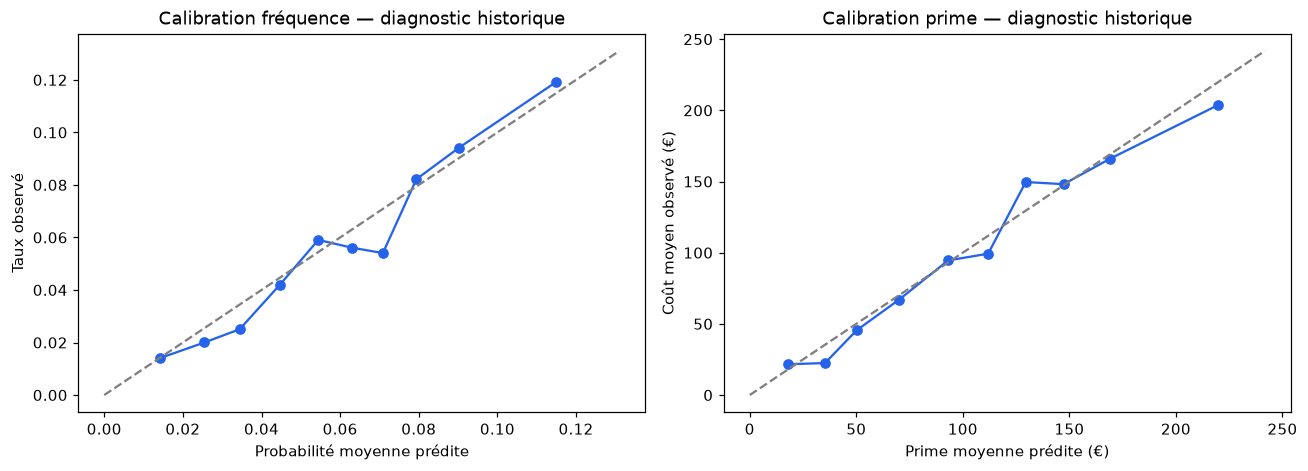

In [4]:
def scores_cout(y,p):
    return {'RMSE_EUR':root_mean_squared_error(y,p),'MSE_EUR2':mean_squared_error(y,p),
        'MAE_EUR':mean_absolute_error(y,p),'biais_EUR':float(np.mean(p-np.asarray(y))),
        'ratio_total':float(np.sum(p)/np.sum(y))}
selected_frequency=F['make'](fconfig).fit(dev,dev.nombre_sinistres,dev.id_client)
claims_dev=dev.loc[dev.nombre_sinistres.eq(1)]
selected_gravity=G['make'](gconfig).fit(claims_dev,claims_dev.montant_sinistre,claims_dev.id_client)
pv=selected_frequency.predict_proba(valid)[:,1];sv=selected_gravity.predict(valid)
old=pd.read_csv(ROOT/'output/prime/predictions_prime_validation.csv')
old=valid[['index']].merge(old,left_on='index',right_on='id',validate='one_to_one',sort=False)
np.testing.assert_allclose(old.cout_reel,valid.montant_sinistre)
historical_scores=pd.DataFrame({
    'Paire_optimisee':scores_cout(valid.montant_sinistre,pv*sv),
    'Paire_precedente':scores_cout(valid.montant_sinistre,old.pred),
    'Prime_constante':scores_cout(valid.montant_sinistre,np.full(len(valid),dev.montant_sinistre.mean()))}).T
historical_scores.to_csv(OUT/'scores_validation_historique.csv',index_label='modele')
details_valid=pd.DataFrame({'index':valid['index'].to_numpy(),'proba_pred':pv,'montant_pred':sv,
    'pred':pv*sv,'nombre_sinistres':valid.nombre_sinistres.to_numpy(),'cout_reel':valid.montant_sinistre.to_numpy()})
details_valid.to_csv(OUT/'predictions_validation_historique.csv',index=False)
display(historical_scores)
mask=valid.nombre_sinistres.eq(1).to_numpy()
component_scores={'log_loss_frequence':log_loss(valid.nombre_sinistres,pv),
    'Brier_frequence':brier_score_loss(valid.nombre_sinistres,pv),'AUC_frequence':roc_auc_score(valid.nombre_sinistres,pv),
    'RMSE_gravite_sinistres':root_mean_squared_error(valid.loc[mask,'montant_sinistre'],sv[mask])}
display(pd.DataFrame([component_scores]))
fig,axes=plt.subplots(1,2,figsize=(12,4.4))
for ax,col,obs,xlabel,ylabel in [(axes[0],'proba_pred','nombre_sinistres','Probabilité moyenne prédite','Taux observé'),
    (axes[1],'pred','cout_reel','Prime moyenne prédite (€)','Coût moyen observé (€)')]:
    temp=details_valid.copy();temp['decile']=pd.qcut(temp[col],10,labels=False,duplicates='drop')
    cal=temp.groupby('decile')[[col,obs]].mean()
    ax.plot(cal[col],cal[obs],'o-',color='#2563eb')
    lim=max(cal.max())*1.1;ax.plot([0,lim],[0,lim],'--',color='grey')
    ax.set(xlabel=xlabel,ylabel=ylabel)
axes[0].set_title('Calibration fréquence — diagnostic historique')
axes[1].set_title('Calibration prime — diagnostic historique')
fig.tight_layout();fig.savefig(OUT/'calibration_paire.png',dpi=160,bbox_inches='tight');display(fig);plt.close(fig)

## 4. Réentraîner les deux modèles finaux et produire les primes

Après le diagnostic, les paramètres retenus restent fixés. La fréquence est réentraînée sur les 50 000 contrats du train ; Gamma sur les 2 917 sinistres. Le test n'apporte aucune cible ni statistique d'apprentissage. Nous sauvegardons séparément les deux modèles et leur assemblage, puis le CSV final et la configuration détaillée.

In [5]:
class TarificationFinale:
    def __init__(self,frequency,gravity):self.frequency=frequency;self.gravity=gravity
    def predict_details(self,X):
        p=self.frequency.predict_proba(X)[:,1];s=self.gravity.predict(X)
        if not np.isfinite(p).all() or not np.isfinite(s).all() or not ((p>=0)&(p<=1)).all() or not (s>0).all():
            raise ValueError('Prédictions hors domaine.')
        return pd.DataFrame({'proba_pred':p,'montant_pred':s,'pred':p*s},index=X.index)
    def predict(self,X):return self.predict_details(X).pred.to_numpy()

frequence_finale=F['make'](fconfig).fit(train,train.nombre_sinistres,train.id_client)
claims_all=train.loc[train.nombre_sinistres.eq(1)]
gravite_finale=G['make'](gconfig).fit(claims_all,claims_all.montant_sinistre,claims_all.id_client)
modele_final=TarificationFinale(frequence_finale,gravite_finale)
details_test=modele_final.predict_details(test)
details_test.insert(0,'index',test['index'].to_numpy())
submission=details_test[['index','pred']].copy()
assert len(submission)==50000 and submission['index'].is_unique
np.testing.assert_array_equal(submission['index'],test['index'])
assert list(submission.columns)==['index','pred'] and np.isfinite(submission.pred).all() and submission.pred.ge(0).all()
for sample_path in [ROOT/'Data/sample_submission.csv',ROOT/'sample_submission.csv']:
    if sample_path.exists():
        sample=pd.read_csv(sample_path)
        assert list(sample.columns)==['index','pred'] and sample['index'].is_unique
        assert set(sample['index'])==set(submission['index'])
        submission=sample[['index']].merge(submission,on='index',validate='one_to_one',sort=False)
submission.to_csv(OUT/'submission.csv',index=False)
details_test.to_csv(OUT/'predictions_test_detaillees.csv',index=False)
for name,obj in [('modele_frequence_final.pkl',frequence_finale),('modele_gravite_final.pkl',gravite_finale),('modele_prime_final.pkl',modele_final)]:
    with (OUT/name).open('wb') as f:cloudpickle.dump(obj,f)
versions={'python':platform.python_version(),'sklearn':sklearn.__version__,'numpy':np.__version__,
    'pandas':pd.__version__,'cloudpickle':cloudpickle.__version__}
config={'frequence':fconfig,'gravite':gconfig,'critere':'MSE de prime hors pli sur 5 plis clients du developpement',
    'nombre_paires_comparees':len(ranking),'RMSE_OOF_selection':float(best.RMSE_prime),
    'validation_imbriquee':nested_scores.to_dict(orient='records'),
    'validation_historique':{name:{k:float(v) for k,v in row.items()} for name,row in historical_scores.iterrows()},
    'validation_historique_deja_examinee':True,'composantes_validation_historique':component_scores,
    'effectifs_finaux':{'frequence':len(train),'gravite':len(claims_all),'prospects':len(test)},
    'colonnes_soumission':['index','pred'],'identifiants_confirmes_par_utilisateur':True,
    'versions':versions,'sha256_data':DATA_HASH,
    'limites':['Meilleure paire parmi les candidats testes, pas optimum universel.',
        'La validation imbriquee concerne le developpement deja explore ; elle nefface pas les choix humains anterieurs.',
        'Les scores historiques ne sont pas des scores Kaggle.']}
(OUT/'configuration_finale.json').write_text(json.dumps(config,ensure_ascii=False,indent=2))
display(Markdown('## MODÈLES FINAUX RETENUS\n\n**Fréquence : '+fconfig['name']+'**\n\n**Gravité : '+gconfig['name']+'**'))
display(submission.head())
print('Soumission générée :',OUT/'submission.csv')

Soumission générée : /data/cours/Data Science/Project/TD-Tarification-automobile-par-Machine-Learning/output/optimisation/prime/submission.csv


## MODÈLES FINAUX RETENUS

**Fréquence : Melange_logistique_boosting_0.75**

**Gravité : Gamma_3_variables_a0.01**

,index,pred
0,50000,56.696763
1,50001,34.776988
2,50002,215.984730
3,50003,120.095202
4,50004,36.937123


## 5. Contrôles de livraison et lecture honnête du résultat

Le modèle doit se recharger dans un nouveau processus, accepter des catégories nouvelles et des valeurs manquantes, et produire les mêmes prédictions à partir des seules variables explicatives. Les versions réelles sont enregistrées dans la configuration. Les anciens notebooks et résultats restent des références pour comparer les gains et diagnostiquer les régressions.

In [6]:
# Rechargement indépendant : aucune variable des notebooks ne doit être nécessaire.
verification="""import sys,cloudpickle,pandas as pd,numpy as np
with open(sys.argv[1],'rb') as f: m=cloudpickle.load(f)
x=pd.read_csv(sys.argv[2],dtype={'code_postal':str},nrows=30)
y=pd.read_csv(sys.argv[3],nrows=30)
p=m.predict_details(x)
for col in ['proba_pred','montant_pred','pred']:
    np.testing.assert_allclose(p[col],y[col],rtol=1e-9,atol=1e-6)
print('Modèle rechargé : probabilités, montants et primes identiques.')
"""
check=subprocess.run([sys.executable,'-c',verification,str(OUT/'modele_prime_final.pkl'),
    str(ROOT/'Data/test.csv'),str(OUT/'predictions_test_detaillees.csv')],capture_output=True,text=True,timeout=120,check=True)
print(check.stdout)
# Le modèle ne doit pas dépendre des cibles ou des identifiants.
probe=train.iloc[:10]
np.testing.assert_allclose(modele_final.predict(probe),modele_final.predict(probe.drop(columns=[
    'index','id_client','id_vehicule','id_contrat','nombre_sinistres','montant_sinistre'])))
probe=test.iloc[:3].copy()
for col in ['modele_vehicule','marque_vehicule','type_contrat','utilisation']:
    probe[col]=probe[col].astype(object)
    probe.loc[probe.index[0],col]='__NOUVEAU__'
    probe.loc[probe.index[1],col]=np.nan
probe.loc[probe.index[0],['poids_vehicule','cylindre_vehicule','anciennete_vehicule']]=np.nan
assert np.isfinite(modele_final.predict(probe)).all()
lu=pd.read_csv(OUT/'submission.csv')
assert list(lu.columns)==['index','pred'] and len(lu)==len(test)
print('Schéma, catégories nouvelles, valeurs manquantes et export vérifiés.')
display(Markdown(f"""
**Sélection OOF : {best.RMSE_prime:.2f} € de RMSE de prime.**

**Procédure imbriquée : {nested_scores.loc[nested_scores.procedure.eq('Selection_paire_imbriquee'),'RMSE'].iloc[0]:.2f} €**, contre
**{nested_scores.loc[nested_scores.procedure.eq('Paire_reference_fixe'),'RMSE'].iloc[0]:.2f} €** pour la paire de référence évaluée sur les mêmes clients externes.

**Diagnostic historique : {historical_scores.loc['Paire_optimisee','RMSE_EUR']:.2f} €**, contre
**{historical_scores.loc['Paire_precedente','RMSE_EUR']:.2f} €** précédemment.

Les différences entre ces scores viennent des populations et du protocole. La sélection OOF est optimiste ; la validation imbriquée évalue une procédure ; le diagnostic historique était déjà connu. Aucun de ces résultats n'est le score Kaggle.

Livraison : `output/optimisation/prime/submission.csv`, **50 000 lignes**, colonnes **index,pred**.
"""))
(BASE_OUTPUT/'progression.json').write_text(json.dumps({'etape':'termine','frequence':fconfig['name'],'gravite':gconfig['name']}));

Modèle rechargé : probabilités, montants et primes identiques.

Schéma, catégories nouvelles, valeurs manquantes et export vérifiés.



**Sélection OOF : 550.21 € de RMSE de prime.**

**Procédure imbriquée : 550.38 €**, contre
**550.39 €** pour la paire de référence évaluée sur les mêmes clients externes.

**Diagnostic historique : 507.60 €**, contre
**507.65 €** précédemment.

Les différences entre ces scores viennent des populations et du protocole. La sélection OOF est optimiste ; la validation imbriquée évalue une procédure ; le diagnostic historique était déjà connu. Aucun de ces résultats n'est le score Kaggle.

Livraison : `output/optimisation/prime/submission.csv`, **50 000 lignes**, colonnes **index,pred**.


## 6. Incertitude et erreurs : le gain est-il convaincant ?

Nous rééchantillonnons **les clients entiers** 2 000 fois et recalculons la différence `RMSE référence − RMSE nouvelle procédure` sur les mêmes tirages. Une valeur positive favorise la nouvelle procédure. L'intervalle est descriptif et conditionnel aux prédictions déjà calculées : nous ne réentraînons pas les modèles dans chaque bootstrap, et il ne mesure donc pas toute l'incertitude d'apprentissage.

La comparaison imbriquée porte sur une **procédure de sélection**, pas sur un unique modèle fixe. La comparaison historique porte sur la paire finale fixée avant ce diagnostic, sur une validation déjà examinée. Si l'intervalle contient zéro, les données ne permettent pas d'affirmer une amélioration nette. Nous ne recommençons pas les réglages jusqu'à obtenir artificiellement un bon score sur cette validation.

Enfin, nous mesurons la part de l'erreur quadratique imputable aux plus gros sinistres : une poignée de montants extrêmes peut déplacer le classement de modèles très proches.

Procedure imbriquee: Le gain ne se distingue pas clairement de zéro.
Diagnostic historique: Le gain ne se distingue pas clairement de zéro.
Les 24 plus gros sinistres (1 % des sinistrés) expliquent 26.2% de l’erreur quadratique imbriquée.


,comparaison,gain_RMSE_EUR,borne_2_5_pct,borne_97_5_pct,clients,repetitions,zero_dans_intervalle
0,Procedure imbriquee,0.005409,-0.119589,0.131731,36628,2000,True
1,Diagnostic historique,0.048346,-0.234674,0.341165,9157,2000,True


,index,cout_reel,pred_procedure,erreur_carree
18605,23265,21826.96,118.717042,4.712478e+08
1903,2408,18246.90,211.346470,3.252812e+08
22197,27721,16859.40,189.726158,2.778780e+08
10330,12864,15997.50,200.879021,2.495332e+08
30777,38429,13813.54,38.488027,1.897521e+08
19973,24967,12069.04,50.477037,1.444459e+08
22011,27492,11906.24,126.978629,1.387510e+08
22232,27763,11724.25,163.294365,1.336557e+08
20811,25981,11509.30,148.023070,1.290786e+08
25299,31573,11484.16,206.641802,1.271824e+08


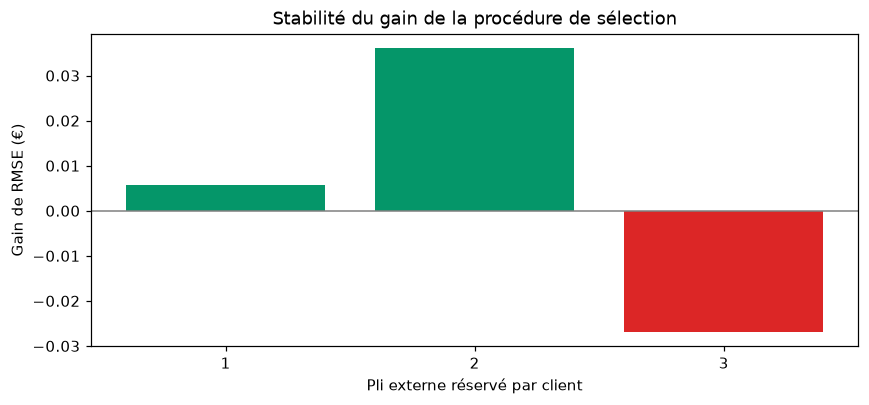

In [7]:
def intervalle_gain_clients(frame, prediction_nouvelle, prediction_reference, repetitions=2000):
    clients=train.set_index('index').id_client.reindex(frame['index']).to_numpy()
    assert pd.notna(clients).all()
    erreurs=pd.DataFrame({'client':clients,
        'reference':(frame.cout_reel.to_numpy()-frame[prediction_reference].to_numpy())**2,
        'nouvelle':(frame.cout_reel.to_numpy()-frame[prediction_nouvelle].to_numpy())**2,'effectif':1})
    sommes=erreurs.groupby('client')[['reference','nouvelle','effectif']].sum().to_numpy()
    rng=np.random.default_rng(20261011);gains=[]
    for debut in range(0,repetitions,50):
        indices=rng.integers(len(sommes),size=(min(50,repetitions-debut),len(sommes)))
        tirages=sommes[indices].sum(axis=1)
        gains.extend(np.sqrt(tirages[:,0]/tirages[:,2])-np.sqrt(tirages[:,1]/tirages[:,2]))
    gain=root_mean_squared_error(frame.cout_reel,frame[prediction_reference])-root_mean_squared_error(frame.cout_reel,frame[prediction_nouvelle])
    lo,hi=np.quantile(gains,[.025,.975])
    return {'gain_RMSE_EUR':gain,'borne_2_5_pct':float(lo),'borne_97_5_pct':float(hi),
        'clients':len(sommes),'repetitions':repetitions,'zero_dans_intervalle':bool(lo<=0<=hi)}

diagnostic_nested=pd.read_csv(OUT/'predictions_validation_imbriquee.csv')
diagnostic_historique=pd.read_csv(OUT/'predictions_validation_historique.csv')
ancienne=pd.read_csv(ROOT/'output/prime/predictions_prime_validation.csv')[['id','pred']].rename(columns={'id':'index','pred':'pred_reference'})
diagnostic_historique=diagnostic_historique.merge(ancienne,on='index',validate='one_to_one',sort=False)
incertitude=pd.DataFrame([
    {'comparaison':'Procedure imbriquee',**intervalle_gain_clients(diagnostic_nested,'pred_procedure','pred_reference')},
    {'comparaison':'Diagnostic historique',**intervalle_gain_clients(diagnostic_historique,'pred','pred_reference')}])
incertitude.to_csv(OUT/'incertitude_gain_clients.csv',index=False)
display(incertitude)
for row in incertitude.to_dict('records'):
    texte='Le gain ne se distingue pas clairement de zéro.' if row['zero_dans_intervalle'] else 'Le signe du gain reste stable dans ce bootstrap descriptif.'
    print(row['comparaison']+': '+texte)

e=diagnostic_nested.copy();e['erreur_carree']=(e.cout_reel-e.pred_procedure)**2
sinistres=e.loc[e.cout_reel.gt(0)].sort_values('cout_reel',ascending=False)
nombre=max(1,int(np.ceil(.01*len(sinistres))))
part=float(sinistres.head(nombre).erreur_carree.sum()/e.erreur_carree.sum())
print(f'Les {nombre} plus gros sinistres (1 % des sinistrés) expliquent {part:.1%} de l’erreur quadratique imbriquée.')
top=sinistres.head(15)[['index','cout_reel','pred_procedure','erreur_carree']]
top.to_csv(OUT/'plus_grosses_erreurs_imbriquees.csv',index=False)
display(top)
fig,ax=plt.subplots(figsize=(8,3.8))
plis=pd.read_csv(OUT/'validation_imbriquee_plis.csv')
gain=plis.RMSE_reference-plis.RMSE_selection
ax.bar(plis.pli_externe.astype(str),gain,color=['#059669' if v>=0 else '#dc2626' for v in gain])
ax.axhline(0,color='grey',linewidth=1)
ax.set(xlabel='Pli externe réservé par client',ylabel='Gain de RMSE (€)',title='Stabilité du gain de la procédure de sélection')
fig.tight_layout();fig.savefig(OUT/'stabilite_gain.png',dpi=160);display(fig);plt.close(fig)
configuration=json.loads((OUT/'configuration_finale.json').read_text())
configuration['incertitude_gain_conditionnelle']=incertitude.to_dict(orient='records')
configuration['part_erreur_top_1_pct_sinistres']=part
(OUT/'configuration_finale.json').write_text(json.dumps(configuration,ensure_ascii=False,indent=2));

## 7. Matrice de confusion : uniquement pour la fréquence

Une matrice de confusion nécessite un seuil pour convertir une probabilité en oui/non. Nous montrons le seuil usuel **0,50** et, à titre pédagogique, le **taux de sinistre du développement**. Ces seuils sont fixés sans chercher le meilleur résultat sur la validation. À faible fréquence, 0,50 peut classer tout le monde « sans sinistre » ; l'exactitude sera alors trompeuse.

La tarification utilise toujours **toutes les probabilités**, multipliées par les montants conditionnels. Aucun de ces seuils ne sert à mettre les primes à zéro. Une matrice de confusion ne convient pas à la régression de gravité : pour celle-ci, nous conservons RMSE, MAE et analyse des erreurs.

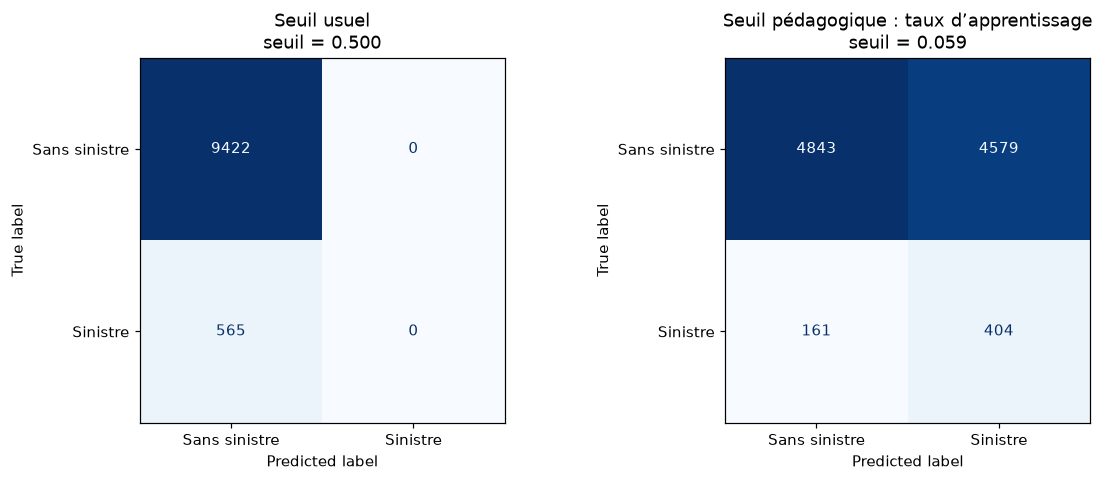

**Fichier à soumettre : `output/optimisation/prime/submission.csv`.** Il contient une prime attendue par prospect. `pred` est cette prime en euros ; la RMSE est une métrique calculée seulement lorsque les coûts réels sont connus.

**Soumission finale prête : `submission.csv`, à la racine du dépôt.** Copie identique archivée dans `output/optimisation/prime/submission.csv`.

In [8]:
from sklearn.metrics import ConfusionMatrixDisplay,confusion_matrix
v=pd.read_csv(OUT/'predictions_validation_historique.csv')
seuils=[('Seuil usuel',.5),('Seuil pédagogique : taux d’apprentissage',float(dev.nombre_sinistres.mean()))]
fig,axes=plt.subplots(1,2,figsize=(11,4.5));matrices=[]
for ax,(titre,seuil) in zip(axes,seuils):
    cm=confusion_matrix(v.nombre_sinistres,v.proba_pred.ge(seuil),labels=[0,1])
    ConfusionMatrixDisplay(cm,display_labels=['Sans sinistre','Sinistre']).plot(ax=ax,colorbar=False,cmap='Blues',values_format='d')
    ax.set_title(f'{titre}\nseuil = {seuil:.3f}')
    matrices.append({'seuil':seuil,'vrais_negatifs':int(cm[0,0]),'faux_positifs':int(cm[0,1]),
        'faux_negatifs':int(cm[1,0]),'vrais_positifs':int(cm[1,1])})
fig.tight_layout();fig.savefig(OUT/'matrices_confusion_frequence.png',dpi=160,bbox_inches='tight');display(fig);plt.close(fig)
pd.DataFrame(matrices).to_csv(OUT/'matrices_confusion_frequence.csv',index=False)
display(Markdown('**Fichier à soumettre : `output/optimisation/prime/submission.csv`.** Il contient une prime attendue par prospect. `pred` est cette prime en euros ; la RMSE est une métrique calculée seulement lorsque les coûts réels sont connus.'))
# Copie finale à la racine du dépôt, facile à retrouver pour Kaggle.
from shutil import copyfile
copyfile(OUT/'submission.csv',ROOT/'submission.csv')
assert hashlib.sha256((OUT/'submission.csv').read_bytes()).digest()==hashlib.sha256((ROOT/'submission.csv').read_bytes()).digest()
display(Markdown('**Soumission finale prête : `submission.csv`, à la racine du dépôt.** Copie identique archivée dans `output/optimisation/prime/submission.csv`.'))


### Ce que nous retenons de cette recherche

La paire finale est le meilleur résultat des **391 paires testées sur les cinq plis de développement**. Le gain est marginal et les intervalles descriptifs incluent zéro : nous ne pouvons pas affirmer qu'elle sera meilleure sur Kaggle. La fréquence historique a même une log-loss légèrement moins bonne malgré la légère baisse de RMSE de prime ; les deux critères n'optimisent pas exactement le même objectif.

Gamma conserve `type_contrat`, `anciennete_vehicule` et `utilisation`, avec `alpha = 0,01`. Les variables supplémentaires et le coût moyen par modèle de voiture n'ont pas apporté de gain suffisant dans cette recherche. Avec seulement 2 917 sinistres au total, certaines catégories disposent de très peu d'exemples ; le lissage évite des estimations trop instables, mais ne crée pas d'information. Ces explications sont des interprétations des résultats, pas des preuves causales.

La principale limite est le bruit des gros sinistres. Pour progresser de façon défendable, les prochains apports utiles seraient davantage de sinistres observés, des caractéristiques pertinentes du dommage disponibles au moment de tarifer, et une validation temporelle lorsque les dates et leur signification seront documentées. Les seuils de classification, l'exposition et les plafonds de garantie ne doivent pas être inventés à partir de champs ambigus.

**Reproduction** : utiliser `requirements_optimisation.txt`, exécuter entièrement `modele_frequence_ameliore.ipynb`, puis `modele_gravite_ameliore.ipynb`, puis ce notebook. Les deux premiers reconstruisent leurs fabriques et leurs catalogues dans le répertoire courant. Relancer leur dernière cellule ensuite permet d'afficher le modèle finalement retenu. Le cache est facultatif, ignoré par Git et recalculé s'il manque. Les versions et empreintes des données sont consignées avec la soumission.